<a href="https://colab.research.google.com/github/tusharviradiya/ai-ml/blob/main/11_Practice/EDA_Diamonds_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# 1. Imports and Setup
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset (53,940 rows, 10 columns)
df = sns.load_dataset("diamonds")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
# 2. Data Inspection & Cleaning
# Check data types and missing values
print("--- Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# Remove zero-dimension anomalies (diamonds cannot have 0mm dimensions)
invalid_dims = (df["x"] == 0) | (df["y"] == 0) | (df["z"] == 0)
print(f"\nDropping {invalid_dims.sum()} rows with 0 dimension values.")
df_cleaned = df[~invalid_dims].copy()

# Feature Engineering: Price per Carat & Volume
df_cleaned["price_per_carat"] = df_cleaned["price"] / df_cleaned["carat"]
df_cleaned["volume"] = df_cleaned["x"] * df_cleaned["y"] * df_cleaned["z"]
df_cleaned.describe()

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None

--- Missing Values ---
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Dropping 20 rows with 0 dimension values.


,carat,depth,table,price,x,y,z,price_per_carat,volume
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046,4007.833685,129.897567
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530,2012.176020,78.219789
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,1051.162791,31.707984
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000,2477.666667,65.189759
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,3494.633257,114.840180
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000,4949.019608,170.846415
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,17828.846154,3840.598060


/tmp/ipykernel_2490/3107228829.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cut", y="price", data=df_cleaned, ax=ax[1], palette="Blues")


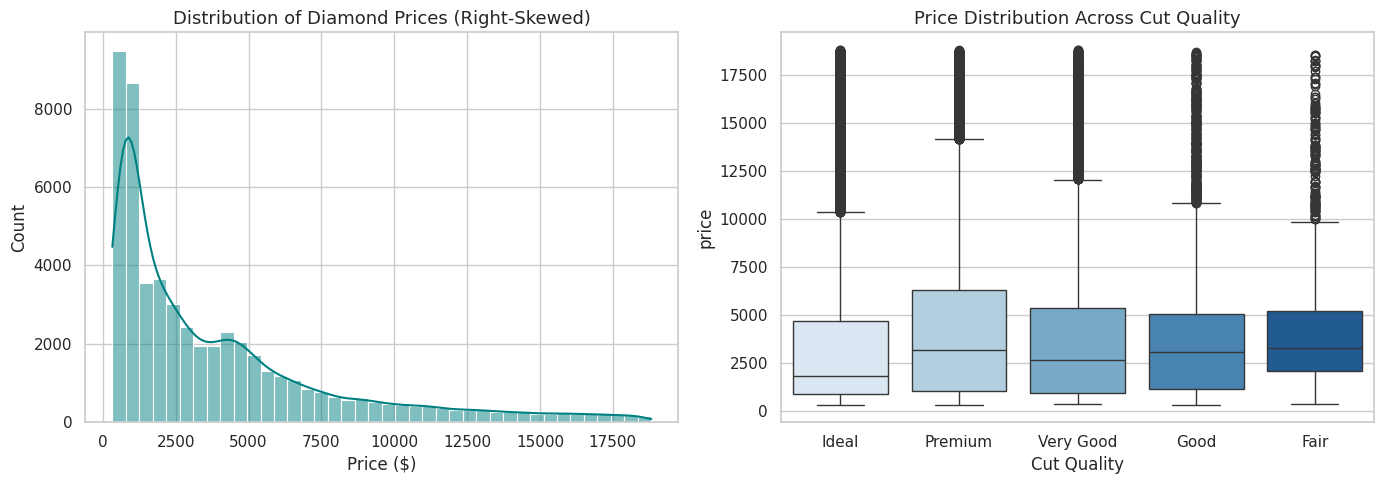

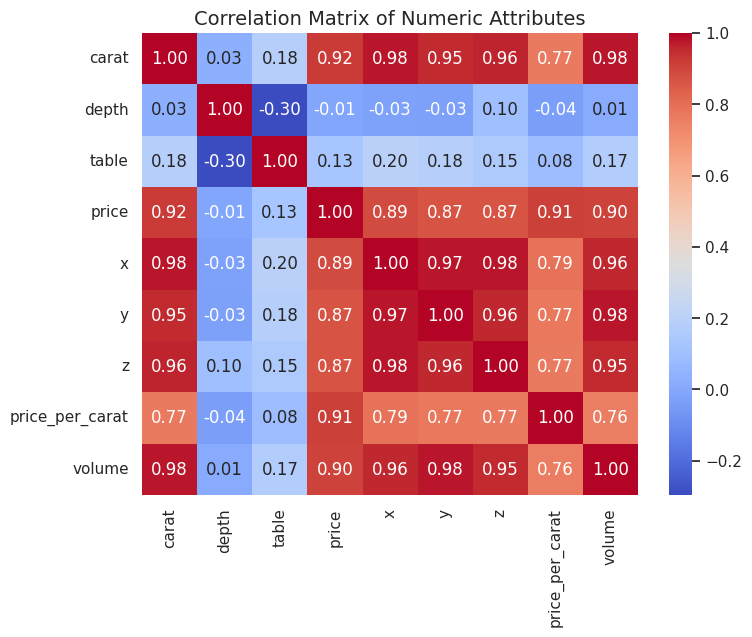

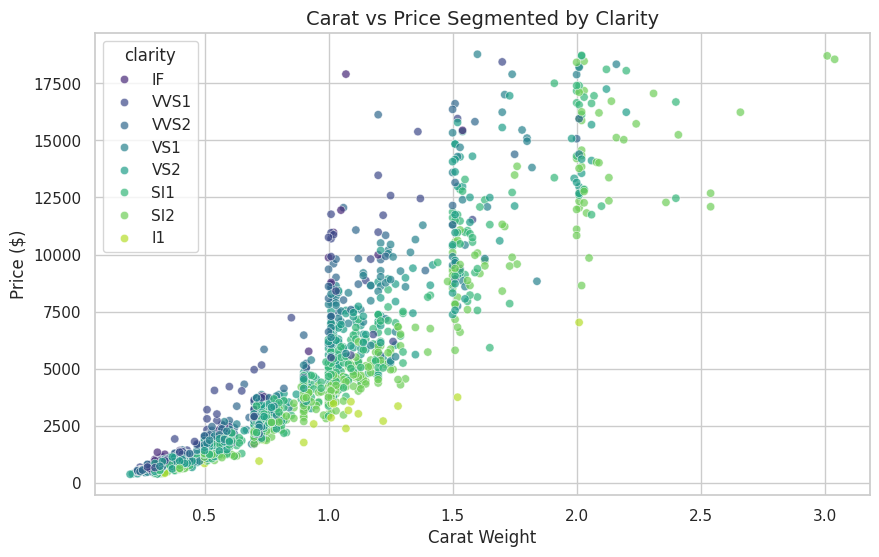

In [10]:
# 3. Exploratory Data Analysis & Visualizations

# Chart 1: Price Distribution (Matplotlib / Seaborn)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_cleaned["price"], bins=40, kde=True, ax=ax[0], color="teal")
ax[0].set_title("Distribution of Diamond Prices (Right-Skewed)", fontsize=13)
ax[0].set_xlabel("Price ($)")

sns.boxplot(x="cut", y="price", data=df_cleaned, ax=ax[1], palette="Blues")
ax[1].set_title("Price Distribution Across Cut Quality", fontsize=13)
ax[1].set_xlabel("Cut Quality")
plt.tight_layout()
plt.show()

# Chart 2: Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df_cleaned.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Attributes", fontsize=14)
plt.show()

# Chart 3: Relationship between Carat, Price, and Clarity
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cleaned.sample(2000, random_state=42),
    x="carat",
    y="price",
    hue="clarity",
    alpha=0.7,
    palette="viridis",
)
plt.title("Carat vs Price Segmented by Clarity", fontsize=14)
plt.xlabel("Carat Weight")
plt.ylabel("Price ($)")
plt.show()

# 4. Final Deliverable Summary

### Dataset Overview
- **Dataset**: Seaborn Diamonds Dataset
- **Total Records Analyzed**: 53,920 records (after removing zero-dimension anomalies) across 12 features.

### Key Insights & Observations
1. **Carat is the primary price driver**: A strong positive correlation ($r \approx 0.92$) exists between carat weight and price.
2. **Right-Skewed Distribution**: Most diamonds are priced below \$3,000, with a long tail extending toward \$18,000.
3. **Clarity Premium**: For any given carat size, higher clarity ratings (`IF`, `VVS1`) demand a substantial markup.

### Recommendations
- **Inventory Sourcing**: Focus on 0.5–1.5 carat diamonds with `Ideal` cuts and `VS1-VS2` clarity, as they provide the highest market liquidity.
- **Pricing Model**: Use non-linear models (e.g., polynomial or logarithmic regressions) to capture the exponential scaling of price relative to carat size.